# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead |Achmad Rizky Akbar| |
| Member | Kajetan Zduńczyk| |
| Member *(optional)* | | |


## 2. Mission Title & Research Question

**Title:** *CEO Turnover and Executive Pay Dispersion in Europe: Evidence from Leadership Changes*

**Research question:** *Does CEO turnover causally change CEO compensation levels and pay dispersion within European firms?*

**Why it matters:** *By focusing on leadership changes observed in BoardEx, we can estimate how compensation responds to a governance shock without hand‑collecting policy data. This helps investors and regulators understand whether turnover acts as a disciplining mechanism on executive pay and internal pay gaps.*

## 3. Data

**Source(s):**  

1. **BoardEx - Individual Profile Employment**

    Includes data about Individual Profile Employment for executives in the BoardEx (Europe) universe.

    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/individual-profile/individual-profile-employment/

2. **BoardEx - Individual Profile Details**

    Includes data about Individual Profile Details for executives in the BoardEx (Europe) universe.

    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/individual-profile/individual-profile-details/

3. **Company Profile Details - BoardEx (Wharton Data Research Services)**

    Company Profile Details includes data such as location, market cap, and sector.
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/company-profile/company-profile-details/

4. **Fundamentals Annual - Compustat Global (Wharton Data Research Services)**

    Provides fundamental annual company information
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/global-daily/fundamentals-annual/

5. **Annual Remuneration - BoardEx (Wharton Data Research Services):**
    
    Data such as salary, bonus, and other cash compensation
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/compensation-analysis/annual-remuneration/

6. **Firms in Stoxx 600 Index**

    STOXX 600 is a major stock index representing the performance of 600 large-, mid-, and small-capitalization companies across 17 developed European countries.

    https://www.stoxx.com/selection-lists

**Unit of observation:** *Executive–year within a firm (linked to firm-year fundamentals and leadership changes).*

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| Total CEO compensation | Numeric | **Target** | Total annual compensation (salary + bonus + other cash/stock, in EUR) |
| Pay dispersion | Numeric | **Target / Outcome** | CEO pay relative to top-executive team (e.g., CEO-to-top-5 ratio) |
| CEO turnover indicator | Binary | **Treatment** | Flag for CEO change in a given year (from BoardEx role start/end) |
| Post‑turnover period | Binary | Feature | Indicator for years after turnover (event window) |
| Firm size (log assets / market cap) | Numeric | Feature | Scale and visibility of firm |
| Profitability (ROA / EBIT margin) | Numeric | Feature | Performance controls |
| Leverage | Numeric | Feature | Capital structure |
| Industry & country fixed effects | Categorical | Feature | Sector and institutional context |
| Executive tenure | Numeric | Feature | Human capital and bargaining power |

**Potential data quality issues:**  
- **Missing compensation components:** use multiple imputation or restrict to firms with complete pay breakdowns; report sensitivity to this choice.
- **Turnover date ambiguity:** define CEO change using role start/end dates and validate with overlapping roles; conduct robustness with alternative windows.
- **Reporting bias / top-coding:** winsorize extreme pay values; compare distributions by country to detect systematic reporting differences.
- **Selection bias in BoardEx coverage:** include a Stoxx 600 filter and check representativeness vs. population benchmarks.
- **Timing misalignment:** align fiscal-year fundamentals with compensation year; drop or lag inconsistent observations.
- **Currency and inflation effects:** convert to EUR and deflate using CPI to ensure comparability across years.

---

In [37]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import wrds
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import statsmodels.formula.api as smf
import networkx as nx
import networkx.algorithms.d_separation as _nxds

# NetworkX 3.x renamed d_separated → is_d_separator; DoWhy 0.8 calls the old name
nx.algorithms.d_separated = _nxds.is_d_separator

from dowhy import CausalModel

In [38]:
DATA_DIR = Path("..") / ".." / "data" / "data_project"

In [39]:
db = wrds.Connection()

# Verify available BoardEx tables (run once to confirm table names)
# boardex_tables = db.list_tables("boardex")
# print([t for t in boardex_tables if any(k in t.lower() for k in ("company","remuner","employ","detail"))])

def load_or_fetch(cache_path, query_fn, label=""):
    """Load from local CSV cache; query WRDS and cache on first run."""
    if cache_path.exists():
        df = pd.read_csv(cache_path, low_memory=False)
        print(f"[cache] {label}: {len(df):,} rows")
    else:
        print(f"[WRDS]  {label}: querying...")
        df = query_fn()
        df.to_csv(cache_path, index=False)
        print(f"[WRDS]  {label}: {len(df):,} rows — cached to {cache_path.name}")
    return df

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [40]:
# STOXX 600 stays as CSV (external index list, not a WRDS table)
df_sxxp = pd.read_csv(DATA_DIR / "stoxx600_clean.csv", sep=";")
stoxx_isins   = tuple(df_sxxp["ISIN"].tolist())
stoxx_isins_s = str(stoxx_isins)   # used inside SQL IN clauses
df_sxxp.head()

,Creation_Date,Internal_Key,ISIN,RIC,Instrument_Name,Country,Currency,Exchange,Index Membership,Rank (FINAL)
0,20260501,546078,NL0010273215,ASML.AS,ASML HLDG,NL,EUR,Euronext Amsterdam,Large,1
1,20260501,40054,GB0005405286,HSBA.L,HSBC,GB,GBP,London SE,Large,2
2,20260501,98952,GB0009895292,AZN.L,ASTRAZENECA,GB,GBP,London SE,Large,3
3,20260501,474577,CH0012032048,ROPC.S,ROCHE PS,CH,CHF,Six Swiss Exchange,Large,4
4,20260501,477408,CH0012005267,NOVN.S,NOVARTIS,CH,CHF,Six Swiss Exchange,Large,5


In [41]:
# STOXX 600 spans EUR, UK, and a few ROW firms (Norway, Switzerland) — query all three regions
# and deduplicate, since a company will only appear in one region table
def _fetch_firm():
    regions = ["eur", "uk", "row"]
    parts = []
    for r in regions:
        try:
            df = db.raw_sql(f"""
                SELECT boardid, isin, boardname, hocountryname, sector,
                       mktcapitalisation, noemployees, revenue
                FROM boardex.{r}_wrds_company_profile
                WHERE isin IN {stoxx_isins_s}
            """)
            parts.append(df)
        except Exception as e:
            print(f"  [{r}] skipped: {e}")
    return pd.concat(parts, ignore_index=True).drop_duplicates("isin")

df_firm = load_or_fetch(DATA_DIR / "company_profile.csv", _fetch_firm, "Company profile")
df_firm.head()

[cache] Company profile: 445,004 rows


,isin,boardname,boardnameshort,hoaddress1,hoaddress2,hoaddress3,hoaddress4,hoaddress5,hocountryname,hotelnumber,...,successorcompanyid,ultimateparentcompanyid,boardid,ticker,countryofquote,primarystock,currency,mktcapitalisation,noemployees,revenue
0,NaN,1955 INVERSIONES SIMCAV SA,1955 INVERSIONES SIMCAV SA,NaN,NaN,NaN,NaN,NaN,Spain,NaN,...,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,FIRST ACTIVE PLC (De-listed 01/2004),FIRST ACTIVE PLC,NaN,NaN,NaN,NaN,NaN,Republic Of Ireland,NaN,...,783081.0,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,FIRST EAGLE FUND NV (De-listed 10/2011),FIRST EAGLE FUND NV,NaN,NaN,NaN,NaN,NaN,Netherlands Antilles,NaN,...,NaN,NaN,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2M INVEST A/S,2M INVEST A/S,NaN,NaN,NaN,NaN,NaN,Denmark,NaN,...,NaN,NaN,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GB0004618236,THREADNEEDLE UK SELECT TRUST LTD (UK Select Tr...,THREADNEEDLE UK SELECT TRUST LTD,Ground Floor Dorey Court,Admiral Park,St Peter Port,NaN,GY1 2HT,Guernsey,+44 (0)1 481 727 111,...,NaN,NaN,296,UKT,ENGLAND AND WALES,Yes,NaN,NaN,NaN,NaN


In [42]:
def _fetch_emp():
    chunk_size = 500
    parts = []
    isin_list = df_sxxp["ISIN"].dropna().str.strip().str.upper().unique().tolist()
    for i in range(0, len(isin_list), chunk_size):
        chunk = tuple(isin_list[i:i + chunk_size])
        parts.append(db.raw_sql("""
            SELECT isin, companyid, companyname, directorid, directorname,
                   rolename, datestartrole, dateendrole, hocountryname
            FROM boardex.eur_wrds_dir_profile_emp
            WHERE isin IN %(isins)s
            ORDER BY companyname, directorname, datestartrole
        """, params={"isins": chunk}))
    return pd.concat(parts, ignore_index=True)

df_emp = load_or_fetch(DATA_DIR / "executives_employment.csv", _fetch_emp, "Employment")
df_emp.head()


[cache] Employment: 95,197 rows


,isin,datestartrole,directorname,companyname,dateendrole,brdposition,rolename,fulltextdescription,ned,primarykeyid,directorid,companyid,hocountryname
0,GB00B1YW4409,1900-01-01,John Yetman,3I GROUP PLC,9999-12-31,No,Executive,Investment Executive,No,1654504,8428,294,United Kingdom - England
1,GB00B1YW4409,2005-07-06,Rod Perry,3I GROUP PLC,9999-12-31,No,Consultant,Also Head of International Advisory Board of V...,No,2003633,11777,294,United Kingdom - England
2,GB00B1YW4409,1900-01-01,John De Zulueta Greenebaum,3I GROUP PLC,9999-12-31,No,Advisor,NaN,No,2542008,6474,294,United Kingdom - England
3,GB00B1YW4409,2007-09-01,Peter Chambré,3I GROUP PLC,2015-12-28,No,Senior Advisor,NaN,No,3034743,26909,294,United Kingdom - England
4,GB00B1YW4409,2005-08-01,Vincent Guillaumot,3I GROUP PLC,2011-12-28,No,Associate Director,NaN,No,8354138,1669563,294,United Kingdom - England


In [43]:
# Director details available via WRDS SQL — query eur + uk + row regions
stoxx_directorids = tuple(df_emp["directorid"].dropna().unique().tolist())

def _fetch_exec():
    regions = ["eur", "uk", "row"]
    parts = []
    for r in regions:
        try:
            df = db.raw_sql(f"""
                SELECT directorid, age, gender
                FROM boardex.{r}_dir_profile_details
                WHERE directorid IN {stoxx_directorids}
            """)
            parts.append(df)
        except Exception as e:
            print(f"  [{r}] skipped: {e}")
    return pd.concat(parts, ignore_index=True).drop_duplicates("directorid")

df_exec = load_or_fetch(DATA_DIR / "executives_profile.csv", _fetch_exec, "Director details")
df_exec.head()

[cache] Director details: 332,924 rows


,directorid,directorname,title,forename1,forename2,forename3,forename4,usualname,surname,suffixtitle,...,dod,age,gender,recreations,directorvisible,dobflag,dodflag,wealthxid,primaryroleid,networksize
0,16,David Shaw,Mr,David,Evans,NaN,NaN,NaN,Shaw,MBA,...,9999-12-31,74.0,M,NaN,Yes,10,55,112260.0,1083314.0,5675.0
1,36,Kevin Kelly,Mr,Kevin,John,NaN,NaN,NaN,Kelly,FCA FCIB,...,2012-01-04,70.0,M,NaN,Yes,10,10,2247015.0,7117.0,NaN
2,37,Klaus Zwickel,Mr,Klaus,NaN,NaN,NaN,NaN,Zwickel,NaN,...,9999-12-31,86.0,M,NaN,Yes,10,55,NaN,3.0,468.0
3,39,Doctor Christopher Albrecht,Doctor,Christopher,J,C,NaN,NaN,Albrecht,PhD,...,9999-12-31,87.0,M,NaN,Yes,10,55,NaN,50962.0,78.0
4,42,Umberto Agnelli,Mr,Umberto,NaN,NaN,NaN,NaN,Agnelli,NaN,...,2004-05-27,69.0,M,NaN,Yes,10,10,NaN,133504.0,NaN


In [44]:
# Filter by boardid (all executives, not just CEOs) — needed for pay dispersion analysis
stoxx_boardids = tuple(df_firm["boardid"].dropna().astype(int).unique().tolist())

def _fetch_renum():
    chunk_size = 500
    parts = []
    boardid_list = list(stoxx_boardids)
    for i in range(0, len(boardid_list), chunk_size):
        chunk = tuple(boardid_list[i:i + chunk_size])
        parts.append(db.raw_sql("""
            SELECT boardid, directorid, annualreportdate, rowtype,
                   salary, bonus, other, totalcompensation, currency, rolename
            FROM boardex.eur_dir_standard_remun
            WHERE boardid IN %(boardids)s
        """, params={"boardids": chunk}))
    return pd.concat(parts, ignore_index=True)

df_renum = load_or_fetch(DATA_DIR / "annual_renumeration.csv", _fetch_renum, "Annual remuneration")
df_renum.head()

[cache] Annual remuneration: 543,033 rows


,boardid,annualreportdate,rowtype,boardname,ned,directorname,rolename,currency,rolestatus,remchgelast,...,ltipvalue,intrvaloptaward,estvaloptaward,toteqatrisk,totremperiod,bonusratio,eqlinkremratio,wealthdelta,totaldirectcomp,perftotal
0,296,2016-12-01,SD Average,THREADNEEDLE UK SELECT TRUST LTD (UK Select Tr...,Yes,NaN,NaN,USD,NaN,0.14,...,NaN,NaN,NaN,NaN,35.0,NaN,NaN,2.0,35.0,NaN
1,296,2017-06-01,SD Average,THREADNEEDLE UK SELECT TRUST LTD (UK Select Tr...,Yes,NaN,NaN,USD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,296,2017-06-01,Board Average,THREADNEEDLE UK SELECT TRUST LTD (UK Select Tr...,No,NaN,NaN,USD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,296,2016-12-01,Board Average,THREADNEEDLE UK SELECT TRUST LTD (UK Select Tr...,No,NaN,NaN,USD,NaN,0.14,...,NaN,NaN,NaN,NaN,35.0,NaN,NaN,2.0,35.0,NaN
4,296,2017-06-01,SD Total,THREADNEEDLE UK SELECT TRUST LTD (UK Select Tr...,Yes,NaN,NaN,USD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Compustat Global fundamentals — cache-first, WRDS on miss
def _fetch_compustat():
    df_sec = db.raw_sql(f"""
        SELECT gvkey, TRIM(isin) AS isin
        FROM comp_global_daily.g_security
        WHERE TRIM(isin) IN {stoxx_isins_s}
    """)
    gvkeys = tuple(df_sec["gvkey"].unique().tolist())
    df_raw = db.raw_sql(f"""
        SELECT gvkey, fyear, datadate, at, sale, ebit, dltt, nicon, teq, cshoi
        FROM comp_global_daily.g_funda
        WHERE gvkey IN {gvkeys}
          AND indfmt  = 'INDL'
          AND datafmt = 'HIST_STD'
          AND consol  = 'C'
          AND popsrc  = 'I'
          AND fyear BETWEEN 2000 AND 2024
    """)
    return df_raw.merge(
        df_sec[["gvkey", "isin"]].drop_duplicates("gvkey"),
        on="gvkey", how="left"
    )

df_cs = load_or_fetch(
    DATA_DIR / "fundamentals_annual.csv",
    _fetch_compustat,
    "Compustat Global fundamentals"
)
print(f"Unique gvkeys: {df_cs['gvkey'].nunique()}")
df_cs.head()


[cache] Compustat Global fundamentals: 9,384 rows
Unique gvkeys: 419


,gvkey,fyear,datadate,at,sale,ebit,dltt,nicon,teq,cshoi,isin
0,1166,2000,2000-12-31,777.940,935.212,191.772,31.660,94.272,NaN,48.797,NL0000334118
1,1166,2001,2001-12-31,757.065,561.064,24.251,142.448,6.098,NaN,49.070,NL0000334118
2,1166,2002,2002-12-31,653.841,518.802,-6.002,117.840,-29.862,NaN,49.370,NL0000334118
3,1166,2003,2003-12-31,672.301,581.868,14.199,179.123,-29.320,NaN,50.062,NL0000334118
4,1166,2004,2004-12-31,823.834,754.245,88.441,193.345,24.039,NaN,52.618,NL0000334118


---
## Step 1: Data Merging & CEO Turnover Events

In [46]:
# --- 1.1  Restrict to STOXX 600 universe ---
stoxx600_isins = set(df_sxxp["ISIN"])
df_firm_sxxp = (
    df_firm[df_firm["isin"].isin(stoxx600_isins)]
    .drop_duplicates(subset=["isin"])
    .copy()
)
stoxx600_boardids = set(df_firm_sxxp["boardid"])

print(f"STOXX 600 ISINs in index:           {len(stoxx600_isins)}")
print(f"Matched firms in BoardEx:           {len(df_firm_sxxp)}")
print(f"Unique board IDs in universe:       {len(stoxx600_boardids)}")
df_firm_sxxp[["isin", "boardid", "boardname", "hocountryname", "sector", "mktcapitalisation"]].head()

STOXX 600 ISINs in index:           600
Matched firms in BoardEx:           466
Unique board IDs in universe:       466


,isin,boardid,boardname,hocountryname,sector,mktcapitalisation
29,NL0000852564,384,AALBERTS NV (Aalberts Industries NV prior to 0...,Netherlands,Engineering & Machinery,3978.0
45,CH0012221716,422,ABB LTD,Switzerland,Engineering & Machinery,182588.0
74,ES0125220311,595,ACCIONA SA,Spain,Renewable Energy,12044.0
75,FR0000120404,598,ACCOR SA,France,Leisure & Hotels,11568.0
83,ES0132105018,626,ACERINOX SA,Spain,Steel & Other Metals,3929.0


In [47]:
# --- 1.2  Identify firm-level CEO spells (Akbar's strict role filtering) ---

# Step A: broad keyword sweep within STOXX 600 firms
# "chief executive" already matches "chief executive officer" as a substring
CEO_PATTERN = r"chief executive|(?<!\w)ceo(?!\w)|managing director"

df_emp_work = df_emp[df_emp["isin"].isin(stoxx600_isins)].copy()
df_emp_work["datestartrole"]     = pd.to_datetime(df_emp_work["datestartrole"], errors="coerce")
df_emp_work["dateendrole_clean"] = pd.to_datetime(
    df_emp_work["dateendrole"].astype(str)
        .replace(["9000-01-01", "9999-12-31", "NaT", "nan", "None"], pd.NA),
    errors="coerce"
)
df_emp_work["rolename_clean"] = df_emp_work["rolename"].fillna("").str.strip()

df_emp_ceo = df_emp_work[
    df_emp_work["rolename_clean"].str.lower().str.contains(CEO_PATTERN, na=False, regex=True)
].copy()

# Step B: strict firm-level filter — exclude divisional, non-actual, subordinate, and interim/acting
has_main_ceo_title  = df_emp_ceo["rolename_clean"].str.contains(
    r"\bCEO\b|Chief Executive|Group CEO|President/CEO"
    r"|Chairman/CEO|Chair/CEO|MD/CEO|CEO/MD|Managing Director",
    case=False, regex=True, na=False
)
exclude_unit_roles  = df_emp_ceo["rolename_clean"].str.contains(
    r"Regional|Division|Divisional|Country|Branch|Sector|Zonal|Area"
    r"|Business Unit|Market|Subsidiary|Segment",
    case=False, regex=True, na=False
)
exclude_non_actual  = df_emp_ceo["rolename_clean"].str.contains(
    r"Designate|Elect|in-Residence|Delegate|Office|Adviser|Advisor"
    r"|Honorary|Shareholder Representative",
    case=False, regex=True, na=False
)
exclude_subordinate = df_emp_ceo["rolename_clean"].str.contains(
    r"Deputy CEO|Vice CEO|Associate CEO|Assistant CEO",
    case=False, regex=True, na=False
)
is_interim_acting   = df_emp_ceo["rolename_clean"].str.contains(
    r"Interim|Acting", case=False, regex=True, na=False
)

df_emp_ceo["firm_level_ceo_strict"] = (
    has_main_ceo_title
    & ~exclude_unit_roles
    & ~exclude_non_actual
    & ~exclude_subordinate
    & ~is_interim_acting
)

print(f"Broad CEO candidates:           {len(df_emp_ceo):,}")
print(f"Strict firm-level CEO spells:   {df_emp_ceo['firm_level_ceo_strict'].sum():,}")
df_emp_ceo[df_emp_ceo["firm_level_ceo_strict"]]["rolename_clean"].value_counts().head(15)

Broad CEO candidates:           6,653
Strict firm-level CEO spells:   1,479


rolename_clean
CEO                             529
President/CEO                   275
Chairman/CEO                    268
Group CEO                        80
CEO/General Manager              31
Co-CEO                           24
CEO/MD                           20
Vice Chairman/CEO                18
Chairman/President/CEO           18
Chair/CEO                        13
President/Group CEO               9
Group President/CEO               9
CEO/MD/General Manager            8
Deputy Group Chief Executive      8
Chairman (Executive)/CEO          8
Name: count, dtype: int64

In [48]:
# --- 1.3  Build df_ceo_main and define CEO turnover events ---

UNKNOWN_START = pd.Timestamp("1900-01-01")

df_ceo_main = (
    df_emp_ceo[df_emp_ceo["firm_level_ceo_strict"]]
    .dropna(subset=["companyid", "directorid", "datestartrole"])
    .loc[lambda x: x["datestartrole"] > UNKNOWN_START]
    .sort_values(["companyid", "datestartrole", "dateendrole_clean", "directorid"])
    .copy()
)

# Turnover: directorid changes at the same company (comparing to previous spell)
df_ceo_main["previous_ceo_directorid"] = (
    df_ceo_main.groupby("companyid")["directorid"].shift()
)
df_ceo_main["ceo_turnover"] = (
    df_ceo_main["directorid"]
    .ne(df_ceo_main["previous_ceo_directorid"])
    .fillna(False).astype(int)
)
# First observed CEO per company is not counted as a turnover event
df_ceo_main.loc[df_ceo_main["previous_ceo_directorid"].isna(), "ceo_turnover"] = 0
df_ceo_main["turnover_year"] = df_ceo_main["datestartrole"].dt.year

# Collapse to firm-year turnover indicator (used for panel merge and event-time)
ceo_turnover_firm_year = (
    df_ceo_main[df_ceo_main["ceo_turnover"] == 1]
    .groupby(["isin", "turnover_year"])
    .size().reset_index(name="num_ceo_turnovers")
    .assign(ceo_turnover=1)
    .rename(columns={"turnover_year": "year"})
)

print(f"Strict CEO spells:            {len(df_ceo_main):,}")
print(f"Unique companies with CEO:    {df_ceo_main['companyid'].nunique():,}")
print(f"CEO turnover events:          {df_ceo_main['ceo_turnover'].sum():,}")
print(f"Firm-year turnover records:   {len(ceo_turnover_firm_year):,}")
df_ceo_main[["companyname", "directorname", "rolename_clean", "datestartrole",
             "dateendrole_clean", "ceo_turnover", "turnover_year"]].head(10)


Strict CEO spells:            1,468
Unique companies with CEO:    503
CEO turnover events:          781
Firm-year turnover records:   747


,companyname,directorname,rolename_clean,datestartrole,dateendrole_clean,ceo_turnover,turnover_year
181,3I GROUP PLC,Simon Borrows,CEO,2012-05-17,NaT,0,2012
209,AALBERTS NV (Aalberts Industries NV prior to 0...,Jan Aalberts,President/CEO,1987-01-01,2012-04-26,0,1987
217,AALBERTS NV (Aalberts Industries NV prior to 0...,Wim Pelsma,CEO,2012-04-26,2023-09-07,1,2012
210,AALBERTS NV (Aalberts Industries NV prior to 0...,Stéphane Simonetta,CEO,2023-09-07,NaT,1,2023
551,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,0,2013
338,ABB LTD,Björn Rosengren,CEO,2020-03-01,2024-07-31,1,2020
504,ABB LTD,Morten Wierod,CEO,2024-08-01,NaT,1,2024
1444,ACCIONA SA,Juan Entrecanales Franco,Vice Chairman/Co-CEO,2004-04-26,2021-09-28,0,2004
1443,ACCIONA SA,José Entrecanales Domecq,Chairman/Co-CEO,2007-01-01,2021-09-28,1,2007
1631,ACCIONA SA,André Clark Juliano,CEO,2016-04-01,2017-09-28,1,2016


In [49]:
# --- 1.4  Expand strict CEO spells to firm-year panel ---
YEAR_MIN, YEAR_MAX = 2000, 2024

df_ceo_main["y_start"] = df_ceo_main["datestartrole"].dt.year.clip(lower=YEAR_MIN)
df_ceo_main["y_end"] = (
    df_ceo_main["dateendrole_clean"].dt.year.fillna(YEAR_MAX).clip(upper=YEAR_MAX)
)
df_ceo_panel = (
    df_ceo_main
    .assign(year=df_ceo_main.apply(lambda r: list(range(int(r.y_start), int(r.y_end) + 1)), axis=1))
    .explode("year")
    .drop_duplicates(subset=["isin", "year"])
    [["isin", "companyid", "year", "directorid"]]
)

print(f"Firm-year CEO observations: {len(df_ceo_panel):,}")
df_ceo_panel.head()

Firm-year CEO observations: 7,487


,isin,companyid,year,directorid
181,GB00B1YW4409,294,2012,342366
181,GB00B1YW4409,294,2013,342366
181,GB00B1YW4409,294,2014,342366
181,GB00B1YW4409,294,2015,342366
181,GB00B1YW4409,294,2016,342366


In [50]:
# --- 1.5  Merge remuneration, firm attributes, and executive demographics ---
df_renum["year"] = pd.to_datetime(df_renum["annualreportdate"], errors="coerce").dt.year

# Individual compensation rows only (exclude board averages and totals)
df_renum_indiv = df_renum[
    df_renum["boardid"].isin(stoxx600_boardids) &
    df_renum["directorid"].notna() &
    ~df_renum["rowtype"].str.lower().str.contains("average|total", na=False)
].sort_values("totalcompensation", ascending=False).drop_duplicates(["boardid", "directorid", "year"])

FIRM_COLS  = ["isin", "boardid", "boardname", "hocountryname", "sector",
              "mktcapitalisation", "noemployees", "revenue"]
RENUM_COLS = ["boardid", "directorid", "year",
              "salary", "bonus", "other", "totalcompensation", "currency", "rolename"]
EXEC_COLS  = ["directorid", "age", "gender"]

df_panel = (
    df_ceo_panel
    .merge(df_firm_sxxp[FIRM_COLS].drop_duplicates("isin"), on="isin", how="left")
    .merge(df_renum_indiv[RENUM_COLS], on=["boardid", "directorid", "year"], how="left")
    .merge(df_exec[EXEC_COLS].drop_duplicates("directorid"), on="directorid", how="left")
    .merge(ceo_turnover_firm_year[["isin", "year", "ceo_turnover"]], on=["isin", "year"], how="left")
)
df_panel["ceo_turnover"] = df_panel["ceo_turnover"].fillna(0).astype(int)

print(f"Panel shape:               {df_panel.shape}")
print(f"Turnover events in panel:  {df_panel['ceo_turnover'].sum()}")
print(f"Compensation coverage:     {df_panel['totalcompensation'].notna().sum():,} / {len(df_panel):,} rows")
df_panel.head()


Panel shape:               (7487, 20)
Turnover events in panel:  674
Compensation coverage:     917 / 7,487 rows


,isin,companyid,year,directorid,boardid,boardname,hocountryname,sector,mktcapitalisation,noemployees,revenue,salary,bonus,other,totalcompensation,currency,rolename,age,gender,ceo_turnover
0,GB00B1YW4409,294,2012,342366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,M,0
1,GB00B1YW4409,294,2013,342366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,M,0
2,GB00B1YW4409,294,2014,342366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,M,0
3,GB00B1YW4409,294,2015,342366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,M,0
4,GB00B1YW4409,294,2016,342366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,M,0


In [51]:
# --- 1.6  Merge Compustat fundamentals ---
# df_cs is already loaded from cache/WRDS in the data-loading section above
df_cs = df_cs.rename(columns={"fyear": "year"})

# Derive financial ratios needed as covariates
df_cs["roa"]         = df_cs["nicon"] / df_cs["at"]
df_cs["ebit_margin"] = df_cs["ebit"]  / df_cs["sale"]
df_cs["leverage"]    = df_cs["dltt"]  / df_cs["at"]
df_cs["log_assets"]  = np.log(df_cs["at"].replace(0, np.nan))

CS_COLS = ["isin", "year", "roa", "ebit_margin", "leverage", "log_assets", "at", "sale"]
df_panel = df_panel.merge(
    df_cs[CS_COLS].drop_duplicates(["isin", "year"]),
    on=["isin", "year"], how="left"
)

print(f"Panel shape after Compustat merge: {df_panel.shape}")
print(f"ROA coverage:       {df_panel['roa'].notna().sum():,} / {len(df_panel):,} rows")
print(f"Leverage coverage:  {df_panel['leverage'].notna().sum():,} / {len(df_panel):,} rows")

df_panel.to_csv(DATA_DIR / "panel_ceo_merged.csv", index=False)
print(f"\nSaved → panel_ceo_merged.csv  [{df_panel.shape[0]:,} rows × {df_panel.shape[1]} cols]")
df_panel[["isin", "year", "boardname", "directorid", "totalcompensation",
          "ceo_turnover", "roa", "leverage", "log_assets"]].head(10)

Panel shape after Compustat merge: (7487, 26)
ROA coverage:       5,378 / 7,487 rows
Leverage coverage:  5,502 / 7,487 rows

Saved → panel_ceo_merged.csv  [7,487 rows × 26 cols]


,isin,year,boardname,directorid,totalcompensation,ceo_turnover,roa,leverage,log_assets
0,GB00B1YW4409,2012,NaN,342366,NaN,0,NaN,NaN,NaN
1,GB00B1YW4409,2013,NaN,342366,NaN,0,NaN,NaN,NaN
2,GB00B1YW4409,2014,NaN,342366,NaN,0,NaN,NaN,NaN
3,GB00B1YW4409,2015,NaN,342366,NaN,0,NaN,NaN,NaN
4,GB00B1YW4409,2016,NaN,342366,NaN,0,NaN,NaN,NaN
5,GB00B1YW4409,2017,NaN,342366,NaN,0,NaN,NaN,NaN
6,GB00B1YW4409,2018,NaN,342366,NaN,0,NaN,NaN,NaN
7,GB00B1YW4409,2019,NaN,342366,NaN,0,NaN,NaN,NaN
8,GB00B1YW4409,2020,NaN,342366,NaN,0,NaN,NaN,NaN
9,GB00B1YW4409,2021,NaN,342366,NaN,0,NaN,NaN,NaN


In [52]:
# --- 1.7  Dynamic market cap from Compustat Global Security Monthly ---
# Price (prccm) from comp.g_secm matched to fiscal year-end via merge_asof.
# Shares outstanding (cshoi) come from g_funda (now in df_cs after cs-load).
# market_cap = prccm × cshoi  (local currency × thousands of shares)

# g_secm stores gvkey as character varying; cast to integer in SQL to match our int params
gvkey_list = df_cs["gvkey"].dropna().astype(int).unique().tolist()

def _fetch_secm():
    chunks = []
    for i in range(0, len(gvkey_list), 500):
        chunk = tuple(gvkey_list[i:i + 500])
        chunks.append(db.raw_sql("""
            SELECT gvkey::integer AS gvkey, iid, datadate, prccm, curcdm, exchg
            FROM comp.g_secm
            WHERE gvkey::integer IN %(gvkeys)s
              AND datadate >= '2000-01-01'
              AND prccm IS NOT NULL
        """, params={"gvkeys": chunk}))
    return pd.concat(chunks, ignore_index=True)

df_secm = load_or_fetch(DATA_DIR / "security_monthly.csv", _fetch_secm, "Compustat security monthly")
df_secm["datadate"] = pd.to_datetime(df_secm["datadate"])
df_secm["gvkey"]    = df_secm["gvkey"].astype(int)

# One listing per gvkey-month (highest price = primary exchange when multiple listings exist)
df_secm_u = (
    df_secm.sort_values(["gvkey", "datadate", "prccm"], ascending=[True, True, False])
    .drop_duplicates(["gvkey", "datadate"])
    .sort_values("datadate")
)

# Use actual fiscal year-end date (datadate from g_funda) — exact, not Dec 31 approximation
df_cs_dated = df_cs.copy()
df_cs_dated["gvkey"]     = df_cs_dated["gvkey"].astype(int)
df_cs_dated["fyear_end"] = pd.to_datetime(df_cs_dated["datadate"])
df_cs_dated = df_cs_dated.sort_values("fyear_end")

df_mktcap = pd.merge_asof(
    df_cs_dated[["gvkey", "isin", "year", "fyear_end", "cshoi"]],
    df_secm_u[["gvkey", "datadate", "prccm"]],
    left_on="fyear_end",
    right_on="datadate",
    by="gvkey",
    direction="nearest",
    tolerance=pd.Timedelta("45 days")
)
df_mktcap["market_cap"]     = df_mktcap["prccm"] * df_mktcap["cshoi"]
df_mktcap["log_market_cap"] = np.log(df_mktcap["market_cap"].replace(0, np.nan))

print(f"Market cap coverage: {df_mktcap['market_cap'].notna().sum():,} / {len(df_mktcap):,} firm-years")

df_panel = df_panel.merge(
    df_mktcap[["isin", "year", "market_cap", "log_market_cap"]].drop_duplicates(["isin", "year"]),
    on=["isin", "year"], how="left"
)
print(f"Panel market_cap:    {df_panel['market_cap'].notna().sum():,} / {len(df_panel):,} rows")
df_mktcap[["isin", "year", "prccm", "cshoi", "market_cap", "log_market_cap"]].dropna().head()


[cache] Compustat security monthly: 303,282 rows
Market cap coverage: 6,936 / 9,384 firm-years
Panel market_cap:    5,085 / 7,487 rows


,isin,year,prccm,cshoi,market_cap,log_market_cap
2009,ES0118594417,2006,19.1886,145.831,2798.292727,7.936765
2010,CH0016440353,2006,150.8000,22.718,3425.874400,8.139112
2012,FI0009000202,2006,40.9000,65.783,2690.524700,7.897492
2013,DE000KSAG888,2006,83.3600,41.250,3438.600000,8.142820
2014,BE0003739530,2006,52.1000,178.326,9290.784600,9.136778


In [53]:
# --- 1.8  Event-time variables and within-firm pay growth ---

# First CEO turnover year per firm (from ceo_turnover_firm_year built in Step 1.3)
first_turnover = (
    ceo_turnover_firm_year.groupby("isin")["year"].min()
    .rename("first_turnover_year").reset_index()
)
df_panel = df_panel.drop(columns=["first_turnover_year", "treated_firm",
    "event_time", "post_turnover", "event_window_3yr", "event_window_5yr"],
    errors="ignore")
df_panel = df_panel.merge(first_turnover, on="isin", how="left")
df_panel["treated_firm"]     = df_panel["first_turnover_year"].notna().astype(int)
df_panel["event_time"]       = (df_panel["year"] - df_panel["first_turnover_year"]).astype("Int64")
df_panel["post_turnover"]    = (df_panel["treated_firm"].eq(1) & df_panel["event_time"].ge(0)).fillna(False).astype(int)
df_panel["event_window_3yr"] = df_panel["event_time"].between(-3, 3).fillna(False).astype(int)
df_panel["event_window_5yr"] = df_panel["event_time"].between(-5, 5).fillna(False).astype(int)

# Within-firm CEO pay growth (nominal; real version via log_w_real_pay after CPI step)
df_panel = df_panel.sort_values(["isin", "year"]).copy()
df_panel["log_totalcompensation"]     = np.log(df_panel["totalcompensation"].replace(0, np.nan))
df_panel["lag_totalcompensation"]     = df_panel.groupby("isin")["totalcompensation"].shift(1)
df_panel["lag_log_totalcompensation"] = df_panel.groupby("isin")["log_totalcompensation"].shift(1)
df_panel["pay_change"]     = df_panel["totalcompensation"] - df_panel["lag_totalcompensation"]
df_panel["pay_change_pct"] = df_panel["pay_change"] / df_panel["lag_totalcompensation"]
df_panel["log_pay_change"] = df_panel["log_totalcompensation"] - df_panel["lag_log_totalcompensation"]

print(f"Treated firm rows:   {df_panel['treated_firm'].sum():,}")
print(f"Post-turnover rows:  {df_panel['post_turnover'].sum():,}")
print(f"Pay growth obs:      {df_panel['log_pay_change'].notna().sum():,}")
df_panel[["isin", "year", "treated_firm", "event_time", "post_turnover",
          "totalcompensation", "log_totalcompensation", "log_pay_change"]].head(10)


Treated firm rows:   6,346
Post-turnover rows:  3,080
Pay growth obs:      645


,isin,year,treated_firm,event_time,post_turnover,totalcompensation,log_totalcompensation,log_pay_change
6033,AT0000606306,2001,1,-12,0,NaN,NaN,NaN
6034,AT0000606306,2002,1,-11,0,NaN,NaN,NaN
6035,AT0000606306,2003,1,-10,0,NaN,NaN,NaN
6036,AT0000606306,2004,1,-9,0,NaN,NaN,NaN
6037,AT0000606306,2005,1,-8,0,NaN,NaN,NaN
6038,AT0000606306,2006,1,-7,0,NaN,NaN,NaN
6039,AT0000606306,2007,1,-6,0,NaN,NaN,NaN
6040,AT0000606306,2008,1,-5,0,NaN,NaN,NaN
6041,AT0000606306,2009,1,-4,0,NaN,NaN,NaN
6042,AT0000606306,2010,1,-3,0,NaN,NaN,NaN


---
## Step 2: Data Cleaning

### 2.1 CPI Deflation (country-specific, base 2015 = 100)

In [54]:
# --- 2.1  Map firm HQ country to ISO-2 ---
COUNTRY_ISO = {
    "Austria": "AT", "Belgium": "BE", "Denmark": "DK", "Finland": "FI",
    "France": "FR", "Germany": "DE", "Ireland": "IE", "Republic Of Ireland": "IE",
    "Italy": "IT", "Luxembourg": "LU", "Netherlands": "NL", "Norway": "NO",
    "Poland": "PL", "Portugal": "PT", "Spain": "ES", "Sweden": "SE",
    "Switzerland": "CH", "United Kingdom": "GB",
    # Crown dependencies → UK prices
    "Isle Of Man": "GB", "Jersey": "GB",
    # US-HQ outliers in BoardEx
    "United States": "US",
}

df_panel["iso2"] = df_panel["hocountryname"].map(COUNTRY_ISO)
# Catch any "United Kingdom - <region>" variants not explicitly in the dict
uk_mask = df_panel["iso2"].isna() & df_panel["hocountryname"].str.startswith("United Kingdom", na=False)
df_panel.loc[uk_mask, "iso2"] = "GB"
unmapped = df_panel[df_panel["iso2"].isna() & df_panel["hocountryname"].notna()]["hocountryname"].unique()
if len(unmapped):
    print(f"Unmapped countries: {unmapped}")
else:
    print("All countries mapped successfully")

# --- 2.2  Fetch CPI from World Bank (cached to avoid repeated API calls) ---
CPI_CACHE = DATA_DIR / "cpi_country_annual.csv"

if CPI_CACHE.exists():
    df_cpi = pd.read_csv(CPI_CACHE)
    print(f"Loaded CPI from cache ({len(df_cpi)} records)")
else:
    iso_codes = sorted(df_panel["iso2"].dropna().unique().tolist())
    records = []
    for iso in iso_codes:
        url = (
            f"https://api.worldbank.org/v2/country/{iso}/indicator/FP.CPI.TOTL"
            f"?date=2000:2024&format=json&per_page=100"
        )
        for attempt in range(3):
            try:
                raw = requests.get(url, timeout=60).json()[1]
                records.extend([
                    {"iso2": d["country"]["id"], "year": int(d["date"]), "cpi": d["value"]}
                    for d in raw if d["value"] is not None
                ])
                break
            except Exception as e:
                print(f"  {iso} attempt {attempt+1} failed: {e}")
                time.sleep(3)
    df_cpi = pd.DataFrame(records)
    df_cpi.to_csv(CPI_CACHE, index=False)
    print(f"Fetched and cached CPI ({len(df_cpi)} records, {df_cpi['iso2'].nunique()} countries)")

# --- 2.3  Rebase to 2015 = 100 ---
cpi_2015 = (
    df_cpi[df_cpi["year"] == 2015]
    .set_index("iso2")["cpi"]
    .rename("cpi_2015")
)
df_cpi = df_cpi.join(cpi_2015, on="iso2")
df_cpi["cpi_idx"] = df_cpi["cpi"] / df_cpi["cpi_2015"] * 100

# --- 2.4  Merge and deflate ---
df_panel = df_panel.merge(
    df_cpi[["iso2", "year", "cpi_idx"]],
    on=["iso2", "year"], how="left"
)

# Compensation (levels only — ratios like ROA/leverage are already real)
for col in ["totalcompensation", "salary", "bonus", "other"]:
    df_panel[f"real_{col}"] = df_panel[col] / df_panel["cpi_idx"] * 100

# Firm fundamentals
df_panel["real_at"]         = df_panel["at"]   / df_panel["cpi_idx"] * 100
df_panel["real_sale"]       = df_panel["sale"] / df_panel["cpi_idx"] * 100
df_panel["real_log_assets"] = np.log(df_panel["real_at"].replace(0, np.nan))

print(f"CPI coverage:  {df_panel['cpi_idx'].notna().sum():,} / {len(df_panel):,} panel rows")
print(f"Real pay rows: {df_panel['real_totalcompensation'].notna().sum():,}")
df_panel[["isin", "year", "hocountryname", "iso2", "cpi_idx",
          "totalcompensation", "real_totalcompensation"]].dropna(subset=["totalcompensation"]).head(8)

All countries mapped successfully
Loaded CPI from cache (450 records)
CPI coverage:  6,951 / 7,487 panel rows
Real pay rows: 917


,isin,year,hocountryname,iso2,cpi_idx,totalcompensation,real_totalcompensation
597,CH0012005267,2016,Switzerland,CH,99.565381,3446.0,3461.042336
630,CH0012214059,2021,Switzerland,CH,101.250369,0.0,0.000000
631,CH0012214059,2022,Switzerland,CH,104.120846,6085.0,5844.170751
632,CH0012214059,2023,Switzerland,CH,106.344243,6954.0,6539.141006
633,CH0012214059,2024,Switzerland,CH,107.473981,1065.0,990.937520
659,CH0012255151,2016,Switzerland,CH,99.565381,4377.0,4396.106298
660,CH0012255151,2017,Switzerland,CH,100.096849,4958.0,4953.202861
661,CH0012255151,2018,Switzerland,CH,101.034092,4858.0,4808.278004


### 2.2 Missing-value Analysis

In [55]:
# --- 2.2  Missing-value summary ---
pay_cols  = ["totalcompensation", "salary", "bonus", "other",
             "real_totalcompensation", "real_salary", "real_bonus", "real_other"]
firm_cols = ["roa", "ebit_margin", "leverage", "real_log_assets"]

miss = pd.DataFrame({
    "non-null":   df_panel[pay_cols + firm_cols].notna().sum(),
    "missing":    df_panel[pay_cols + firm_cols].isna().sum(),
    "coverage %": (df_panel[pay_cols + firm_cols].notna().mean() * 100).round(1)
})
print(f"Panel rows: {len(df_panel):,}")
display(miss)

# Compensation coverage by year
pay_by_year = (
    df_panel.groupby("year")["totalcompensation"]
    .agg(n_obs="count", n_total="size")
    .assign(pct=lambda x: (x["n_obs"] / x["n_total"] * 100).round(1))
)
print("\nCompensation coverage by year:")
display(pay_by_year[pay_by_year["n_obs"] > 0])

# Compensation coverage by country
pay_by_country = (
    df_panel.groupby("hocountryname")["totalcompensation"]
    .agg(n_obs="count", n_total="size")
    .assign(pct=lambda x: (x["n_obs"] / x["n_total"] * 100).round(1))
    .sort_values("pct", ascending=False)
)
print("\nCompensation coverage by country:")
display(pay_by_country)

Panel rows: 7,487


,non-null,missing,coverage %
totalcompensation,917,6570,12.2
salary,824,6663,11.0
bonus,705,6782,9.4
other,754,6733,10.1
real_totalcompensation,917,6570,12.2
real_salary,824,6663,11.0
real_bonus,705,6782,9.4
real_other,754,6733,10.1
roa,5378,2109,71.8
ebit_margin,5501,1986,73.5



Compensation coverage by year:


,n_obs,n_total,pct
year,,,
2016,97,409,23.7
2017,100,417,24.0
2018,104,421,24.7
2019,101,428,23.6
2020,99,425,23.3
2021,101,425,23.8
2022,99,432,22.9
2023,108,434,24.9
2024,108,441,24.5



Compensation coverage by country:


,n_obs,n_total,pct
hocountryname,,,
Jersey,7,8,87.5
United Kingdom - England,34,59,57.6
Republic Of Ireland,62,120,51.7
Isle Of Man,7,16,43.8
Germany,257,905,28.4
France,272,1045,26.0
Luxembourg,18,93,19.4
Netherlands,81,498,16.3
Spain,62,410,15.1


### 2.3 Winsorization of Pay (p1 / p99)

In [56]:
# --- 2.3  Winsorize real compensation at p1/p99 (among non-null rows) ---
def winsorize_series(s, lo=0.01, hi=0.99):
    """Clip to [p1, p99]; NaN-safe."""
    q_lo, q_hi = s.quantile([lo, hi])
    return s.clip(lower=q_lo, upper=q_hi)

real_pay_cols = ["real_totalcompensation", "real_salary", "real_bonus", "real_other"]
for col in real_pay_cols:
    df_panel[f"w_{col}"] = winsorize_series(df_panel[col])

# Log of winsorized total pay (used as dependent variable in regressions)
df_panel["log_w_real_pay"] = np.log(df_panel["w_real_totalcompensation"].replace(0, np.nan))

# Quick sanity check
stats = df_panel[["real_totalcompensation", "w_real_totalcompensation", "log_w_real_pay"]].describe()
display(stats)

# How many rows clipped at each tail?
p1  = df_panel["real_totalcompensation"].quantile(0.01)
p99 = df_panel["real_totalcompensation"].quantile(0.99)
n_lo = (df_panel["real_totalcompensation"] < p1).sum()
n_hi = (df_panel["real_totalcompensation"] > p99).sum()
print(f"\np1={p1:,.0f}, p99={p99:,.0f}")
print(f"Rows clipped at lower tail: {n_lo}")
print(f"Rows clipped at upper tail: {n_hi}")


,real_totalcompensation,w_real_totalcompensation,log_w_real_pay
count,917.000000,917.000000,824.000000
mean,2445.008831,2434.579213,7.732105
std,1565.082887,1526.630337,0.732911
min,0.000000,0.000000,0.482343
25%,1433.099605,1433.099605,7.461983
50%,2354.683045,2354.683045,7.840131
75%,3380.221185,3380.221185,8.158555
max,11418.598363,6801.231072,8.824859



p1=0, p99=6,801
Rows clipped at lower tail: 0
Rows clipped at upper tail: 10


### 2.4 Save Clean Panel

In [57]:
# --- 2.4  Persist the clean panel ---
PANEL_CLEAN = DATA_DIR / "panel_clean.csv"
df_panel.to_csv(PANEL_CLEAN, index=False)
print(f"Saved: {PANEL_CLEAN}")
print(f"Shape: {df_panel.shape}")
print(f"Columns: {df_panel.columns.tolist()}")

Saved: ../../data/data_project/panel_clean.csv
Shape: (7487, 54)
Columns: ['isin', 'companyid', 'year', 'directorid', 'boardid', 'boardname', 'hocountryname', 'sector', 'mktcapitalisation', 'noemployees', 'revenue', 'salary', 'bonus', 'other', 'totalcompensation', 'currency', 'rolename', 'age', 'gender', 'ceo_turnover', 'roa', 'ebit_margin', 'leverage', 'log_assets', 'at', 'sale', 'market_cap', 'log_market_cap', 'first_turnover_year', 'treated_firm', 'event_time', 'post_turnover', 'event_window_3yr', 'event_window_5yr', 'log_totalcompensation', 'lag_totalcompensation', 'lag_log_totalcompensation', 'pay_change', 'pay_change_pct', 'log_pay_change', 'iso2', 'cpi_idx', 'real_totalcompensation', 'real_salary', 'real_bonus', 'real_other', 'real_at', 'real_sale', 'real_log_assets', 'w_real_totalcompensation', 'w_real_salary', 'w_real_bonus', 'w_real_other', 'log_w_real_pay']


---
## Step 3: EDA & Descriptive Statistics

In [58]:
# ── Load panel & coverage overview ────────────────────────────────────────────
DATA_DIR = Path("..") / ".." / "data" / "data_project"

df = pd.read_csv(DATA_DIR / "panel_clean.csv")
df["event_time"] = pd.array(df["event_time"], dtype="Int64")

n_firms   = df["isin"].nunique()
n_treated = df.groupby("isin")["treated_firm"].first().sum()

print(f"Panel shape          : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Unique firms (ISINs) : {n_firms:,}")
print(f"Year range           : {df['year'].min()} – {df['year'].max()}")
print(f"Countries            : {df['hocountryname'].nunique()}")
print(f"CEO turnover events  : {df['ceo_turnover'].sum():,}")
print(f"Treated firms        : {n_treated:.0f}  ({n_treated/n_firms*100:.1f}% of firms)")
print(f"Pay observable       : {df['totalcompensation'].notna().sum():,} ({df['totalcompensation'].notna().mean()*100:.1f}%)")
print(f"Market cap obs.      : {df['market_cap'].notna().sum():,} ({df['market_cap'].notna().mean()*100:.1f}%)")
print(f"Compustat obs.       : {df['roa'].notna().sum():,} ({df['roa'].notna().mean()*100:.1f}%)")

print("\nFirm count by country (top 12):")
display(
    df.groupby("hocountryname")["isin"].nunique()
    .sort_values(ascending=False).head(12)
    .rename("Unique firms").to_frame()
)

Panel shape          : 7,487 rows × 54 cols
Unique firms (ISINs) : 503
Year range           : 2000.0 – 2024.0
Countries            : 20
CEO turnover events  : 674
Treated firms        : 386  (76.7% of firms)
Pay observable       : 917 (12.2%)
Market cap obs.      : 5,085 (67.9%)
Compustat obs.       : 5,378 (71.8%)

Firm count by country (top 12):


,Unique firms
hocountryname,
Germany,65
France,62
Switzerland,57
Sweden,45
Italy,36
Netherlands,33
Spain,26
Denmark,21
Norway,20


In [59]:
# ── Descriptive statistics ─────────────────────────────────────────────────────
KEY_VARS = {
    "log_w_real_pay":           "Log real CEO pay (winsorized)",
    "w_real_totalcompensation": "Real total comp. (EUR, winsorized)",
    "w_real_salary":            "Real salary (EUR, winsorized)",
    "w_real_bonus":             "Real bonus (EUR, winsorized)",
    "log_market_cap":           "Log market cap",
    "log_assets":               "Log total assets",
    "roa":                      "ROA",
    "ebit_margin":              "EBIT margin",
    "leverage":                 "Leverage (LTD/assets)",
    "age":                      "CEO age",
    "pay_change_pct":           "YoY pay change (%)",
}

desc = (
    df[list(KEY_VARS)]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .T
    .rename(columns={
        "count": "N", "mean": "Mean", "std": "Std",
        "min": "Min", "10%": "p10", "25%": "p25",
        "50%": "p50", "75%": "p75", "90%": "p90", "max": "Max"
    })
)
desc.index = desc.index.map(KEY_VARS)
desc["N"] = desc["N"].astype(int)
display(desc.round(3))

,N,Mean,Std,Min,p10,p25,p50,p75,p90,Max
Log real CEO pay (winsorized),824,7.732,0.733,0.482,7.053,7.462,7.840,8.159,8.409,8.825
"Real total comp. (EUR, winsorized)",917,2434.579,1526.630,0.000,0.000,1433.100,2354.683,3380.221,4337.335,6801.231
"Real salary (EUR, winsorized)",824,1348.858,583.329,159.134,815.307,981.975,1258.515,1575.922,2010.681,3620.784
"Real bonus (EUR, winsorized)",705,1591.165,923.663,16.015,545.797,936.886,1453.825,2103.397,2848.105,4344.102
Log market cap,5085,9.703,1.988,3.321,7.525,8.374,9.365,10.833,12.445,18.555
Log total assets,5502,9.298,1.627,3.137,7.268,8.306,9.290,10.441,11.485,13.802
ROA,5378,0.058,0.116,-0.978,0.002,0.025,0.050,0.080,0.123,2.518
EBIT margin,5501,-inf,NaN,-inf,0.030,0.062,0.113,0.178,0.261,0.996
Leverage (LTD/assets),5502,0.195,0.129,0.000,0.020,0.102,0.186,0.274,0.364,0.813
CEO age,7298,64.367,7.591,40.000,54.000,59.250,64.000,69.000,74.000,92.000


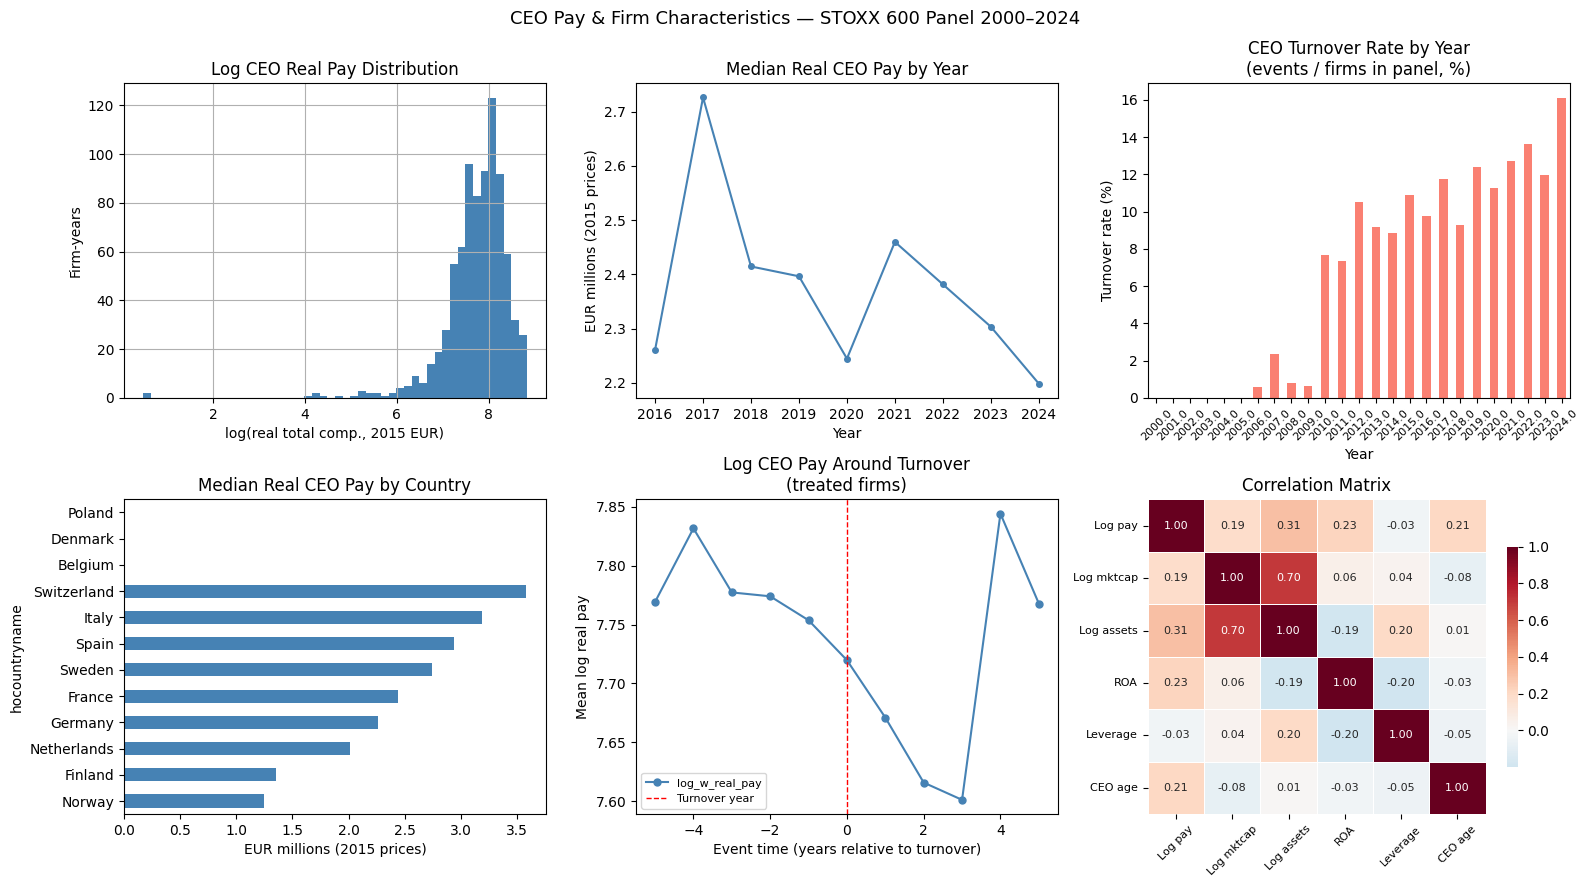

In [60]:
# ── Six-panel visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("CEO Pay & Firm Characteristics — STOXX 600 Panel 2000–2024", fontsize=13)

# 1. Log CEO pay distribution
ax = axes[0, 0]
df["log_w_real_pay"].dropna().hist(bins=50, ax=ax, color="steelblue", edgecolor="none")
ax.set_title("Log CEO Real Pay Distribution")
ax.set_xlabel("log(real total comp., 2015 EUR)")
ax.set_ylabel("Firm-years")

# 2. Median real CEO pay over time
# BoardEx stores compensation in EUR thousands → /1e3 converts to EUR millions
ax = axes[0, 1]
pay_yr = df.groupby("year")["w_real_totalcompensation"].median() / 1e3
pay_yr.plot(ax=ax, marker="o", color="steelblue", linewidth=1.5, markersize=4)
ax.set_title("Median Real CEO Pay by Year")
ax.set_xlabel("Year")
ax.set_ylabel("EUR millions (2015 prices)")

# 3. CEO turnover rate per year (events / firms in panel)
ax = axes[0, 2]
n_firms_yr = df.groupby("year")["isin"].nunique()
turn_yr    = df[df["ceo_turnover"] == 1].groupby("year").size()
turn_rate  = (turn_yr / n_firms_yr * 100).fillna(0)
turn_rate.plot(kind="bar", ax=ax, color="salmon", edgecolor="none")
ax.set_title("CEO Turnover Rate by Year\n(events / firms in panel, %)")
ax.set_xlabel("Year"); ax.set_ylabel("Turnover rate (%)")
ax.tick_params(axis="x", rotation=45, labelsize=8)

# 4. Median real pay by country (top 12 by firm count)
ax = axes[1, 0]
top_c = df.groupby("hocountryname")["isin"].nunique().nlargest(12).index
cntry = (
    df[df["hocountryname"].isin(top_c)]
    .groupby("hocountryname")["w_real_totalcompensation"]
    .median() / 1e3
).sort_values()
cntry.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Median Real CEO Pay by Country")
ax.set_xlabel("EUR millions (2015 prices)")

# 5. Mean log pay by event time (treated firms only)
ax = axes[1, 1]
et = (
    df[df["treated_firm"].eq(1) & df["event_time"].between(-5, 5)]
    .groupby("event_time")["log_w_real_pay"].mean()
)
et.plot(ax=ax, marker="o", color="steelblue", linewidth=1.5, markersize=5)
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="Turnover year")
ax.set_title("Log CEO Pay Around Turnover\n(treated firms)")
ax.set_xlabel("Event time (years relative to turnover)")
ax.set_ylabel("Mean log real pay")
ax.legend(fontsize=8)

# 6. Correlation heatmap
ax = axes[1, 2]
corr_cols   = ["log_w_real_pay", "log_market_cap", "log_assets", "roa", "leverage", "age"]
corr_labels = ["Log pay", "Log mktcap", "Log assets", "ROA", "Leverage", "CEO age"]
sns.heatmap(
    df[corr_cols].corr(), ax=ax, cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", linewidths=0.5,
    xticklabels=corr_labels, yticklabels=corr_labels,
    cbar_kws={"shrink": 0.7}, annot_kws={"size": 8}
)
ax.set_title("Correlation Matrix")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

Cross-firm CEO pay dispersion metrics by year:


,year,n,mean,median,std,cv,gini,p90_p10
0,2000.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2001.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2002.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2003.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2004.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2005.0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2006.0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2007.0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2008.0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2009.0,0,NaN,NaN,NaN,NaN,NaN,NaN



Saved → pay_dispersion_yearly.csv


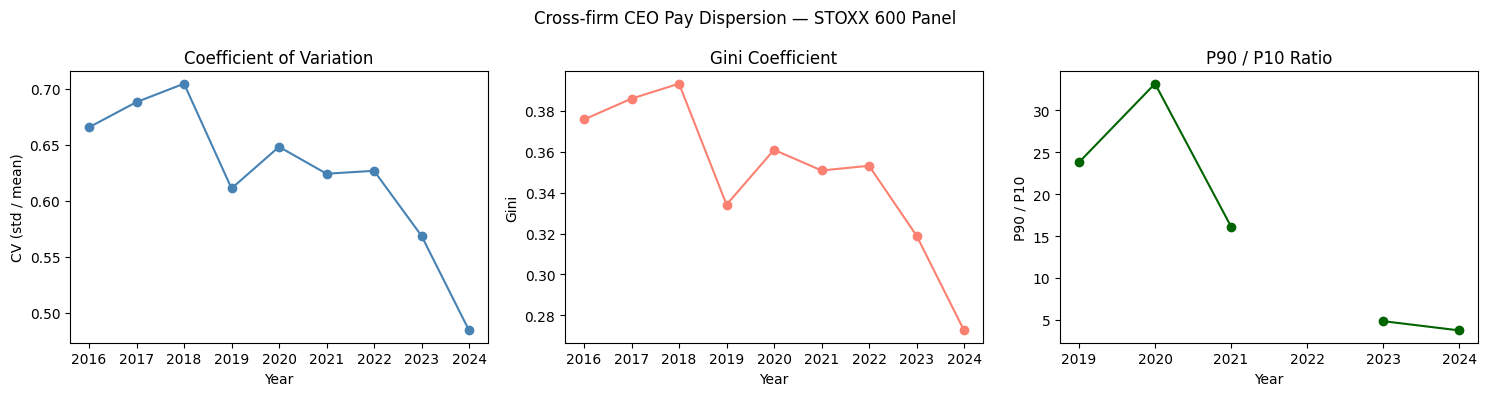

In [61]:
# ── Pay dispersion metrics ────────────────────────────────────────────────────
def gini_coeff(x):
    x = np.sort(x[~np.isnan(x)])
    n = len(x)
    if n < 2:
        return np.nan
    idx = np.arange(1, n + 1)
    return (2 * np.dot(idx, x) / (n * x.sum())) - (n + 1) / n

disp = (
    df.groupby("year")["w_real_totalcompensation"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        cv=lambda x: x.std() / x.mean(),
        gini=gini_coeff,
        p90_p10=lambda x: x.quantile(0.9) / x.quantile(0.1),
    )
    .round(4)
    .reset_index()
)
print("Cross-firm CEO pay dispersion metrics by year:")
display(disp)

disp.to_csv(DATA_DIR / "pay_dispersion_yearly.csv", index=False)
print(f"\nSaved → pay_dispersion_yearly.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Cross-firm CEO Pay Dispersion — STOXX 600 Panel", fontsize=12)

panels = [
    ("cv",      "Coefficient of Variation", "CV (std / mean)", "steelblue"),
    ("gini",    "Gini Coefficient",          "Gini",           "salmon"),
    ("p90_p10", "P90 / P10 Ratio",           "P90 / P10",      "darkgreen"),
]
for ax, (col, title, ylabel, color) in zip(axes, panels):
    disp.plot(x="year", y=col, ax=ax, marker="o", color=color, legend=False)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Year")

plt.tight_layout()
plt.show()

Pay coverage by year:


'  year  n_firms  n_pay  coverage_pct\n2000.0       39      0           0.0\n2001.0       46      0           0.0\n2002.0       60      0           0.0\n2003.0       79      0           0.0\n2004.0       95      0           0.0\n2005.0      136      0           0.0\n2006.0      169      0           0.0\n2007.0      210      0           0.0\n2008.0      256      0           0.0\n2009.0      307      0           0.0\n2010.0      326      0           0.0\n2011.0      339      0           0.0\n2012.0      352      0           0.0\n2013.0      371      0           0.0\n2014.0      384      0           0.0\n2015.0      404      0           0.0\n2016.0      409     97          23.7\n2017.0      417    100          24.0\n2018.0      421    104          24.7\n2019.0      428    101          23.6\n2020.0      425     99          23.3\n2021.0      425    101          23.8\n2022.0      432     99          22.9\n2023.0      434    108          24.9\n2024.0      441    108          24.5'

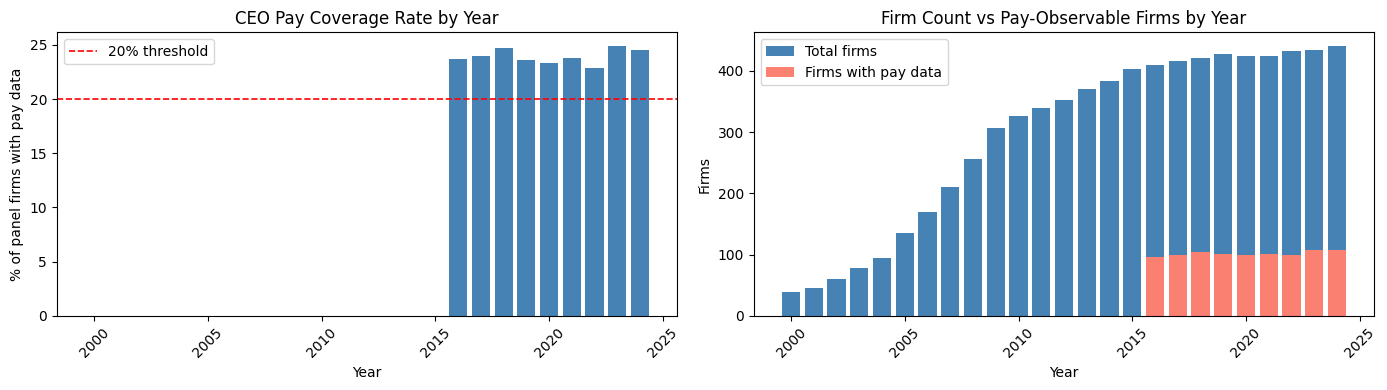

In [62]:
# ── Pay coverage by year ───────────────────────────────────────────────────────
cov = (
    df.groupby("year")
    .agg(n_firms=("isin", "nunique"), n_pay=("totalcompensation", "count"))
    .reset_index()
)
cov["coverage_pct"] = (cov["n_pay"] / cov["n_firms"] * 100).round(1)

print("Pay coverage by year:")
display(cov.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(cov["year"], cov["coverage_pct"], color="steelblue", edgecolor="none")
axes[0].axhline(20, color="red", linestyle="--", linewidth=1.2, label="20% threshold")
axes[0].set_title("CEO Pay Coverage Rate by Year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("% of panel firms with pay data")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(cov["year"], cov["n_firms"], color="steelblue", edgecolor="none", label="Total firms")
axes[1].bar(cov["year"], cov["n_pay"],   color="salmon",    edgecolor="none", label="Firms with pay data")
axes[1].set_title("Firm Count vs Pay-Observable Firms by Year")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Firms")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [63]:
# ── Filter: restrict to years with ≥20% pay coverage ─────────────────────────
# BoardEx remuneration covers ~100 of ~400 firms per year (~24% ceiling).
# 30% is unattainable; 20% selects the window where pay data first appears.
COVERAGE_THRESHOLD = 20  # percent

years_ok = cov.loc[cov["coverage_pct"] >= COVERAGE_THRESHOLD, "year"].tolist()
print(f"Years with ≥{COVERAGE_THRESHOLD}% pay coverage: {min(years_ok)} – {max(years_ok)}")
print(f"  ({len(years_ok)} years retained out of {len(cov)})")

df_analysis = df[df["year"].isin(years_ok)].copy()

print(f"\nFull panel   : {df.shape[0]:,} rows, {df['isin'].nunique():,} firms")
print(f"Analysis     : {df_analysis.shape[0]:,} rows, {df_analysis['isin'].nunique():,} firms")
print(f"Pay coverage : {df_analysis['totalcompensation'].notna().mean()*100:.1f}%  "
      f"({df_analysis['totalcompensation'].notna().sum():,} rows with pay)")
print(f"Turnover events retained : {df_analysis['ceo_turnover'].sum():,}")
print(f"Treated firms retained   : {df_analysis.groupby('isin')['treated_firm'].first().sum():.0f}")
print()
print("Note: regression models will further restrict to non-null pay rows.")
print("The effective N for pay regressions is the 'rows with pay' figure above.")

PANEL_ANALYSIS = DATA_DIR / "panel_analysis.csv"
df_analysis.to_csv(PANEL_ANALYSIS, index=False)
print(f"\nSaved → panel_analysis.csv  [{df_analysis.shape[0]:,} rows × {df_analysis.shape[1]} cols]")

Years with ≥20% pay coverage: 2016.0 – 2024.0
  (9 years retained out of 25)

Full panel   : 7,487 rows, 503 firms
Analysis     : 3,832 rows, 482 firms
Pay coverage : 23.9%  (917 rows with pay)
Turnover events retained : 465
Treated firms retained   : 386

Note: regression models will further restrict to non-null pay rows.
The effective N for pay regressions is the 'rows with pay' figure above.

Saved → panel_analysis.csv  [3,832 rows × 54 cols]


---
## Step 4: Causal Inference

Regression sample : 695 rows, 104 firms
Treated (turnover): 603 rows  (91 firms)
Year range        : 2016.0 – 2024.0
Backdoor adjustment set: ['leverage', 'sector', 'hocountryname', 'roa', 'log_assets']
── DiD: effect of post-turnover period on log CEO pay ──
  post_turnover coef : -0.2080
  95% CI             : [-0.3230, -0.0929]
  p-value            : 0.0004
  N                  : 695,  R² = 0.388


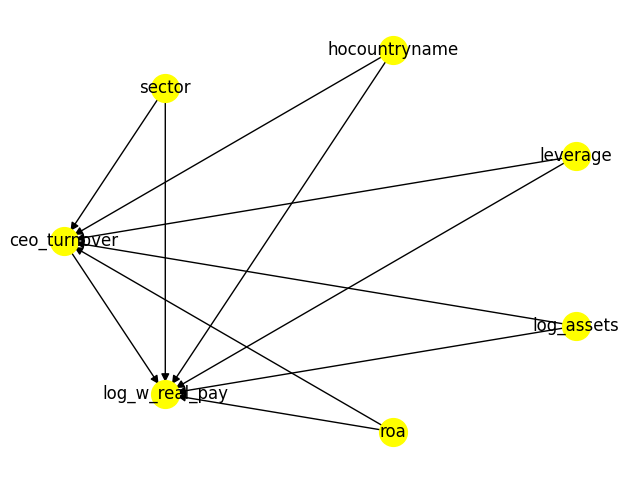

In [64]:
# ── Step 4: Causal Inference ────────────────────────────────────────────

# Load analysis panel; restrict to pay-observable rows for regressions
df_a = pd.read_csv(DATA_DIR / "panel_analysis.csv")
df_a["event_time"] = pd.array(df_a["event_time"], dtype="Int64")

# Regression sample: rows with pay and at least one Compustat covariate
df_reg = df_a[
    df_a["log_w_real_pay"].notna() &
    df_a["log_assets"].notna() &
    df_a["roa"].notna()
].copy()

print(f"Regression sample : {len(df_reg):,} rows, {df_reg['isin'].nunique()} firms")
print(f"Treated (turnover): {df_reg['treated_firm'].sum()} rows  "
      f"({df_reg.groupby('isin')['treated_firm'].first().sum():.0f} firms)")
print(f"Year range        : {df_reg['year'].min()} – {df_reg['year'].max()}")

# ── 4.1  Causal DAG (DoWhy) ────────────────────────────────────────────
causal_graph = """
digraph {
    ceo_turnover        -> log_w_real_pay;
    roa                 -> ceo_turnover;
    roa                 -> log_w_real_pay;
    log_assets          -> ceo_turnover;
    log_assets          -> log_w_real_pay;
    leverage            -> ceo_turnover;
    leverage            -> log_w_real_pay;
    hocountryname       -> ceo_turnover;
    hocountryname       -> log_w_real_pay;
    sector              -> ceo_turnover;
    sector              -> log_w_real_pay;
}
"""

model = CausalModel(
    data=df_reg,
    treatment="ceo_turnover",
    outcome="log_w_real_pay",
    graph=causal_graph,
)
model.view_model()

# Identify the backdoor adjustment set
identified = model.identify_effect(proceed_when_unidentifiable=True)
adj_set = identified.get_backdoor_variables()
print(f"Backdoor adjustment set: {adj_set}")

# ── 4.2  DiD regression (operationalises backdoor adjustment) ────────────────
formula = (
    "log_w_real_pay ~ treated_firm + post_turnover "
    "+ roa + log_assets + leverage "
    "+ C(year) + C(hocountryname) + C(sector)"
)
res_did = smf.ols(formula, data=df_reg).fit(cov_type="HC3")

print("── DiD: effect of post-turnover period on log CEO pay ──")
print(f"  post_turnover coef : {res_did.params['post_turnover']:.4f}")
print(f"  95% CI             : [{res_did.conf_int().loc['post_turnover', 0]:.4f}, "
      f"{res_did.conf_int().loc['post_turnover', 1]:.4f}]")
print(f"  p-value            : {res_did.pvalues['post_turnover']:.4f}")
print(f"  N                  : {int(res_did.nobs)},  R² = {res_did.rsquared:.3f}")


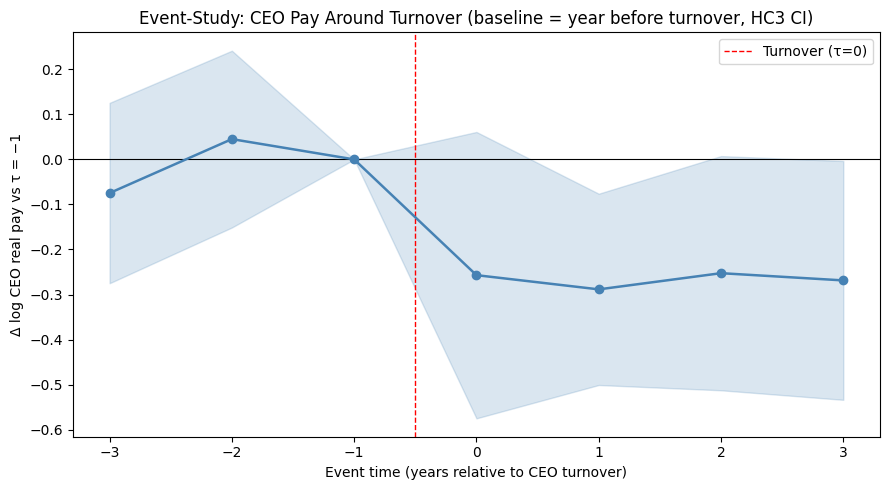

Event-study sample: 335 rows  (treated in window: 243,  control rows: 92)
── Event-time coefficients (log pay vs baseline τ=−1):
  τ = -3:  β = -0.0747  [-0.2749, +0.1255]  
  τ = -2:  β = +0.0451  [-0.1512, +0.2413]  
  τ = -1:  β = +0.0000  [+0.0000, +0.0000]  ← baseline
  τ = +0:  β = -0.2570  [-0.5749, +0.0609]  
  τ = +1:  β = -0.2886  [-0.5009, -0.0762]  
  τ = +2:  β = -0.2526  [-0.5126, +0.0074]  
  τ = +3:  β = -0.2687  [-0.5338, -0.0036]  


In [65]:
# ── 4.4  Event-study regression (Sun & Abraham style, manual) ────────────────
# Regress log pay on event-time dummies (τ = -3…+3) for treated firms,
# omitting τ = -1 as the baseline. Control firms contribute to year FE.
# treated_firm absorbs the pre-period level difference between treated/control.
# Columns named et_m3…et_p3 ("m"=minus, "p"=plus) to avoid patsy parsing
# hyphens in et_-3 as subtraction.

es_sample = df_reg[
    (df_reg["treated_firm"].eq(1) & df_reg["event_time"].between(-3, 3))
    | df_reg["treated_firm"].eq(0)
].copy()

def tau_col(t):
    return f"et_m{abs(t)}" if t < 0 else f"et_p{t}"

for tau in range(-3, 4):
    if tau == -1:
        continue
    es_sample[tau_col(tau)] = (
        (es_sample["treated_firm"].eq(1)) &
        (es_sample["event_time"] == tau)
    ).fillna(False).astype(int)

et_terms = " + ".join(tau_col(t) for t in range(-3, 4) if t != -1)
formula_es = (
    f"log_w_real_pay ~ {et_terms} + treated_firm "
    "+ roa + log_assets + leverage "
    "+ C(year) + C(hocountryname) + C(sector)"
)
res_es = smf.ols(formula_es, data=es_sample).fit(cov_type="HC3")

# Collect τ coefficients and CIs (τ = -1 is the omitted baseline → 0)
taus_full = list(range(-3, 4))
coef_dict = {
    t: (0.0, 0.0, 0.0) if t == -1
    else (
        res_es.params.get(tau_col(t), np.nan),
        res_es.conf_int().loc[tau_col(t), 0] if tau_col(t) in res_es.params else np.nan,
        res_es.conf_int().loc[tau_col(t), 1] if tau_col(t) in res_es.params else np.nan,
    )
    for t in taus_full
}
coefs_full = [coef_dict[t][0] for t in taus_full]
ci_lo_full = [coef_dict[t][1] for t in taus_full]
ci_hi_full = [coef_dict[t][2] for t in taus_full]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(-0.5, color="red", linestyle="--", linewidth=1, label="Turnover (τ=0)")
ax.fill_between(taus_full, ci_lo_full, ci_hi_full, alpha=0.2, color="steelblue")
ax.plot(taus_full, coefs_full, marker="o", color="steelblue", linewidth=1.8, markersize=6)
ax.set_xticks(taus_full)
ax.set_xlabel("Event time (years relative to CEO turnover)")
ax.set_ylabel("Δ log CEO real pay vs τ = −1")
ax.set_title("Event-Study: CEO Pay Around Turnover (baseline = year before turnover, HC3 CI)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Event-study sample: {len(es_sample):,} rows  "
      f"(treated in window: {es_sample[es_sample['treated_firm']==1].shape[0]},  "
      f"control rows: {(es_sample['treated_firm']==0).sum()})")

print("── Event-time coefficients (log pay vs baseline τ=−1):")
for t, c, lo, hi in zip(taus_full, coefs_full, ci_lo_full, ci_hi_full):
    marker = "← baseline" if t == -1 else ""
    print(f"  τ = {t:+d}:  β = {c:+.4f}  [{lo:+.4f}, {hi:+.4f}]  {marker}")

---
## Step 5: Supervised Learning

In [66]:
# Supervised learning analysis

---
## Step 6: Unsupervised / Generative

In [67]:
# Unsupervised / generative analysis

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [X] Causal graph / DAG (DoWhy)
- [X] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:* We will model CEO turnover as a governance shock in a DAG and use backdoor adjustment to control for firm fundamentals that affect both turnover and pay. We will estimate the causal effect of turnover using pre/post (event‑study style) comparisons around the turnover year.

### 4b. Supervised Learning
- [X] Linear / Ridge / Lasso regression
- [X] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [X] Decision Tree / Random Forest
- [X] Gradient Boosting (XGBoost / LightGBM / sklearn GBM)
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:* Supervised models will benchmark expected compensation conditional on firm and executive characteristics. Linear models provide interpretable baselines and covariate effects, while tree-based and boosting models capture nonlinearities/interactions for more accurate counterfactual pay predictions. We will use Optuna to tune boosting hyperparameters (e.g., depth, learning rate, subsampling) to avoid overfitting and compare against simpler baselines.

### 4c. Unsupervised Learning / Generative Models
- [X] K-Means clustering
- [ ] Hierarchical clustering
- [X] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* Clustering will segment firms into comparable peer groups before causal estimation and highlight heterogeneous effects across turnover regimes. A VAE will learn low-dimensional representations of firm/executive profiles to detect anomalous pay structures and support exploratory subgroup analysis.

## 5. Evaluation Strategy

*How will you know if your mission succeeded? Describe:*

- RMSE


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Achmad | Data collection & merging from BoardEx/Compustat; define CEO turnover events |
| 2 | Kajetan | Data cleaning, missing-value strategy, currency/inflation adjustments |
| 3 | Achmad | EDA + descriptive stats; define pay dispersion metrics |
| 4 | Kajetan | Causal inference block (DAG, event-window design around turnover, ATE estimation) |
| 5 | Achmad | Supervised learning benchmark models + heterogeneity analysis |
| 6 | Kajetan | Unsupervised/generative clustering/embeddings; peer-group analysis |
| 7 | Achmad + Kajetan | Synthesis, robustness checks, and final write-up |


---
## 7. Results *(complete for final submission)*


## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
